<a href='https://www.darshan.ac.in/'> <img src='https://www.darshan.ac.in/Content/media/DU_Logo.svg' width="250" height="300"/></a>
<pre>
<center><b><h1>Machine Learning - 2301CS621</b></center>

<center><b><h1>Lab - 4 - Polynomial Regression</b></center>    
<pre>    

# Importing the libraries

/Users/jayesh/opt/anaconda3/lib/python3.9/site-packages/scipy/__init__.py:146: UserWarning: A NumPy version >=1.16.5 and <1.23.0 is required for this version of SciPy (detected version 1.26.4
  warnings.warn(f"A NumPy version >={np_minversion} and <{np_maxversion}"


# Importing the libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn as s

In [3]:
df = pd.read_csv('Position_Salaries.csv')
df

,Position,Level,Salary
0,Business Analyst,1,45000
1,Junior Consultant,2,50000
2,Senior Consultant,3,60000
3,Manager,4,80000
4,Country Manager,5,110000
5,Region Manager,6,150000
6,Partner,7,200000
7,Senior Partner,8,300000
8,C-level,9,500000
9,CEO,10,1000000


# Plot the data using scatter plot

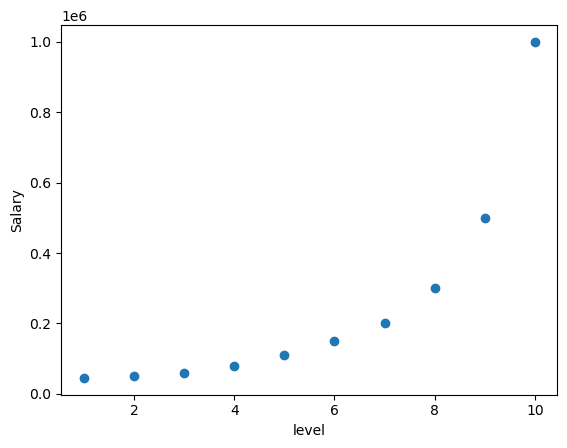

In [5]:
plt.scatter(df['Level'], df['Salary'])
plt.xlabel("level")
plt.ylabel("Salary")
plt.show()

In [9]:
x = df[["Level"]]
x

,Level
0,1
1,2
2,3
3,4
4,5
5,6
6,7
7,8
8,9
9,10


# Splitting the dataset into the Training set and Test set

In [11]:
y = df[["Salary"]]
y

,Salary
0,45000
1,50000
2,60000
3,80000
4,110000
5,150000
6,200000
7,300000
8,500000
9,1000000


In [21]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test = train_test_split(x,y, test_size=0.3,random_state=42)
print("x_train",x_train.shape)
print("x_test",x_test.shape)
print("y_train",y_train.shape)
print("y_test",y_test.shape)

x_train (7, 1)
x_test (3, 1)
y_train (7, 1)
y_test (3, 1)


# Fitting Linear Regression to the dataset

In [23]:
from sklearn.linear_model import LinearRegression

In [27]:
model = LinearRegression()
model.fit(x_train,y_train)

LinearRegression()

# Predict the x_test using Linear Model

In [29]:
x_pred = model.predict(x_test)


# Visualising the Linear Regression results

In [31]:
x_pred

array([[575160.89108911],
       [-49554.45544554],
       [307425.74257426]])

array([ 596551.72413793,  299568.96551724, -195402.29885057])

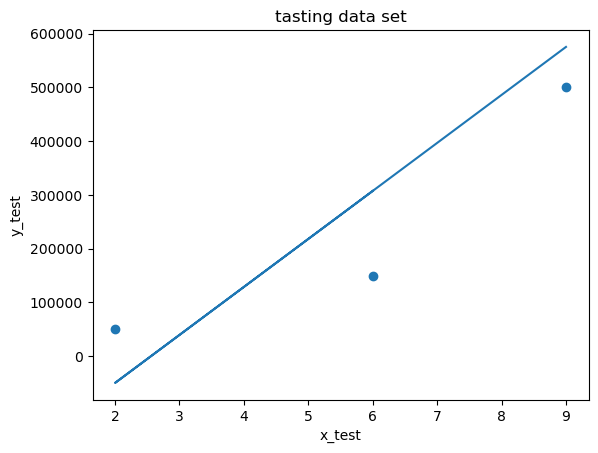

In [39]:
plt.scatter(x_test,y_test)
plt.plot(x_test,x_pred)
plt.xlabel("x_test")
plt.ylabel("y_test")
plt.title("tasting data set")
plt.show()

In [41]:
from sklearn.metrics import mean_squared_error
rmse = np.sqrt(mean_squared_error(y_test,x_pred))

In [43]:
rmse

115964.2381274276

# Fitting Polynomial Regression to the dataset

## import  PolynomialFeatures

In [48]:
from sklearn.preprocessing import PolynomialFeatures

## create PolynomialFeatures of degree 4

In [62]:
poly = PolynomialFeatures(degree=4)
poly

PolynomialFeatures(degree=4)

## Apply fit_transform to features

In [64]:
x_poly = poly.fit_transform(x_train)

## View new  Features

In [66]:
x_poly

array([[1.000e+00, 1.000e+00, 1.000e+00, 1.000e+00, 1.000e+00],
       [1.000e+00, 8.000e+00, 6.400e+01, 5.120e+02, 4.096e+03],
       [1.000e+00, 3.000e+00, 9.000e+00, 2.700e+01, 8.100e+01],
       [1.000e+00, 1.000e+01, 1.000e+02, 1.000e+03, 1.000e+04],
       [1.000e+00, 5.000e+00, 2.500e+01, 1.250e+02, 6.250e+02],
       [1.000e+00, 4.000e+00, 1.600e+01, 6.400e+01, 2.560e+02],
       [1.000e+00, 7.000e+00, 4.900e+01, 3.430e+02, 2.401e+03]])

## Fitting Polynomial Regression to the dataset

In [72]:
poly.fit(x_poly, y_train)
poly_reg = LinearRegression()


In [88]:
poly_reg.fit(x_poly,y_train)

LinearRegression()

# Create Grid for higher resolution and smoother curve

# Predict the x_test using Polynomial Regression

In [90]:
x_test


,Level
8,9
1,2
5,6


In [92]:
poly.fit_transform(x_test)

array([[1.000e+00, 9.000e+00, 8.100e+01, 7.290e+02, 6.561e+03],
       [1.000e+00, 2.000e+00, 4.000e+00, 8.000e+00, 1.600e+01],
       [1.000e+00, 6.000e+00, 3.600e+01, 2.160e+02, 1.296e+03]])

In [94]:
y_poly_prid = poly_reg.predict(poly.fit_transform(x_test))

# Visualising the Linear Regression results

In [96]:
y_test

,Salary
8,500000
1,50000
5,150000


In [102]:
x_pred

array([[575160.89108911],
       [-49554.45544554],
       [307425.74257426]])

In [98]:
y_poly_prid

array([[550738.27849056],
       [ 30679.16278174],
       [139190.58942538]])

array([534753.92278604, 148214.11999257,  47014.83400916])

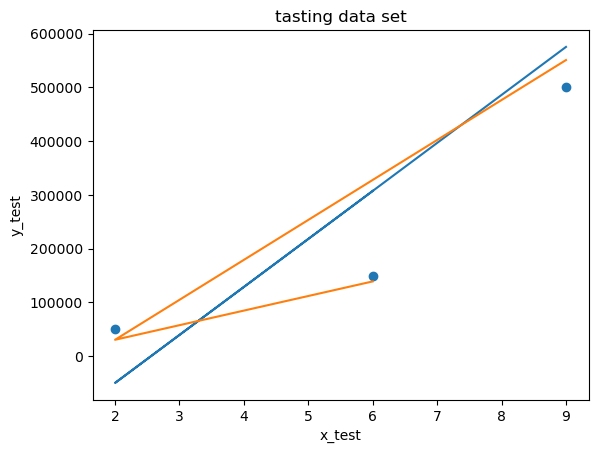

In [104]:
plt.scatter(x_test,y_test)
plt.plot(x_test,x_pred)
plt.plot(x_test,y_poly_prid)
plt.xlabel("x_test")
plt.ylabel("y_test")
plt.title("tasting data set")
plt.show()

array([[1. ],
       [1.1],
       [1.2],
       [1.3],
       [1.4],
       [1.5],
       [1.6],
       [1.7],
       [1.8],
       [1.9],
       [2. ],
       [2.1],
       [2.2],
       [2.3],
       [2.4],
       [2.5],
       [2.6],
       [2.7],
       [2.8],
       [2.9],
       [3. ],
       [3.1],
       [3.2],
       [3.3],
       [3.4],
       [3.5],
       [3.6],
       [3.7],
       [3.8],
       [3.9],
       [4. ],
       [4.1],
       [4.2],
       [4.3],
       [4.4],
       [4.5],
       [4.6],
       [4.7],
       [4.8],
       [4.9],
       [5. ],
       [5.1],
       [5.2],
       [5.3],
       [5.4],
       [5.5],
       [5.6],
       [5.7],
       [5.8],
       [5.9],
       [6. ],
       [6.1],
       [6.2],
       [6.3],
       [6.4],
       [6.5],
       [6.6],
       [6.7],
       [6.8],
       [6.9],
       [7. ],
       [7.1],
       [7.2],
       [7.3],
       [7.4],
       [7.5],
       [7.6],
       [7.7],
       [7.8],
       [7.9],
       [8. ],
      

array([ 47014.83400916,  47124.23463931,  47263.16344879,  47436.17210049,
        47647.94562377,  47903.25337985,  48206.90233109,  48563.69317001,
        48978.37966438,  49455.63140477,  50000.00000001,  50615.88865094,
        51307.52494372,  52078.93663772,  52933.93017923,  53876.07164833,
        54908.66984132,  56034.76120354,  57257.09635465,  58578.12799059,
        60000.00000002,  61524.53769804,  63153.23915375,  64887.26766953,
        66727.44555756,  68674.24945041,  70727.80747738,  72887.8987336 ,
        75153.95556413,  77525.06927843,  80000.00000001,  82577.19144028,
        85254.79146293,  88030.67937423,  90902.50093334,  93867.7121241 ,
        96923.63276372, 100067.51104296, 103296.60009509, 106608.24767564,
       110000.00000001, 113469.72072985, 117015.72602001, 120636.93643462,
       124333.04641118, 128104.71179458, 131953.7557767 , 135883.39335991,
       139898.47421337, 144005.7435075 , 148214.11999257, 152534.99023116,
       156982.51749882, 1

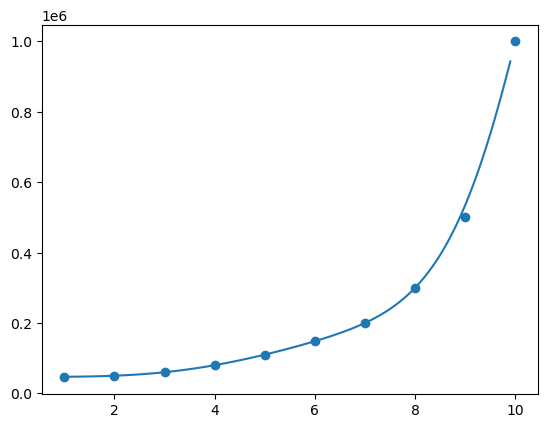

In [59]:
plt.scatter(x,y)
plt.plot(new_x,y_all)